# Part 5 — Design decisions, analysis, report figuresLoads frozen JSON from results/ and rebuilds figures/tables for the report.

In [1]:
from google.colab import drive
drive.mount("/content/drive")
import os
DRIVE="/content/drive/MyDrive/svg_scaling_v2"
print("ready")

Mounted at /content/drive
ready


In [2]:
!pip install -q numpy matplotlib scipy seaborn

In [3]:
import json,numpy as np,matplotlib.pyplot as plt,seaborn as sns
from scipy.optimize import curve_fit
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi":150,"savefig.dpi":200,"savefig.bbox":"tight"})
def power_law(N,a,alpha,c):return a*np.power(N,-alpha)+c
print("imports done")

imports done


## 5.1 Load all results

In [4]:
with open(f"{DRIVE}/data/meta.json") as f:meta=json.load(f)
with open(f"{DRIVE}/results/sp_results.json") as f:sp_res=json.load(f)
with open(f"{DRIVE}/results/mup_results.json") as f:mup_res=json.load(f)
with open(f"{DRIVE}/results/lr_sweep.json") as f:lr_sp=json.load(f)
with open(f"{DRIVE}/results/mup_lr_sweep.json") as f:lr_mup=json.load(f)
with open(f"{DRIVE}/results/sp_fit.json") as f:sp_fit=json.load(f)
with open(f"{DRIVE}/results/mup_fit.json") as f:mup_fit=json.load(f)
with open(f"{DRIVE}/results/extrapolation.json") as f:extrap=json.load(f)
with open(f"{DRIVE}/results/eval_metrics.json") as f:metrics=json.load(f)

def _pc(d,n):
    x=d[n]
    return int(x.get("n_params",x.get("params",0)))

MODELS=list(sp_res.keys())
sp_params=np.array([_pc(sp_res,n) for n in MODELS])
sp_losses=np.array([sp_res[n]["val"] for n in MODELS])
mup_params=np.array([_pc(mup_res,n) for n in MODELS])
mup_losses=np.array([mup_res[n]["val"] for n in MODELS])
popt_sp=np.array([sp_fit["a"],sp_fit["alpha"],sp_fit["c"]])
popt_mup=np.array([mup_fit["a"],mup_fit["alpha"],mup_fit["c"]])
xf=np.logspace(np.log10(sp_params.min()*0.3),np.log10(sp_params.max()*15),200)
print("all data loaded")

all data loaded


In [5]:
with open(f"{DRIVE}/data/meta.json") as f:meta=json.load(f)
with open(f"{DRIVE}/results/sp_results.json") as f:sp_res=json.load(f)
with open(f"{DRIVE}/results/mup_results.json") as f:mup_res=json.load(f)
with open(f"{DRIVE}/results/lr_sweep.json") as f:lr_sp=json.load(f)
with open(f"{DRIVE}/results/mup_lr_sweep.json") as f:lr_mup=json.load(f)
with open(f"{DRIVE}/results/sp_fit.json") as f:sp_fit=json.load(f)
with open(f"{DRIVE}/results/mup_fit.json") as f:mup_fit=json.load(f)
with open(f"{DRIVE}/results/extrapolation.json") as f:extrap=json.load(f)
with open(f"{DRIVE}/results/eval_metrics.json") as f:metrics=json.load(f)

def _pc(d,n):
    x=d[n]
    return int(x.get("n_params",x.get("params",0)))

MODELS=list(sp_res.keys())
sp_params=np.array([_pc(sp_res,n) for n in MODELS])
sp_losses=np.array([sp_res[n]["val"] for n in MODELS])
mup_params=np.array([_pc(mup_res,n) for n in MODELS])
mup_losses=np.array([mup_res[n]["val"] for n in MODELS])
popt_sp=np.array([sp_fit["a"],sp_fit["alpha"],sp_fit["c"]])
popt_mup=np.array([mup_fit["a"],mup_fit["alpha"],mup_fit["c"]])
xf=np.logspace(np.log10(sp_params.min()*0.3),np.log10(sp_params.max()*15),200)
print("all data loaded")

all data loaded


## 5.2 Main scaling plot

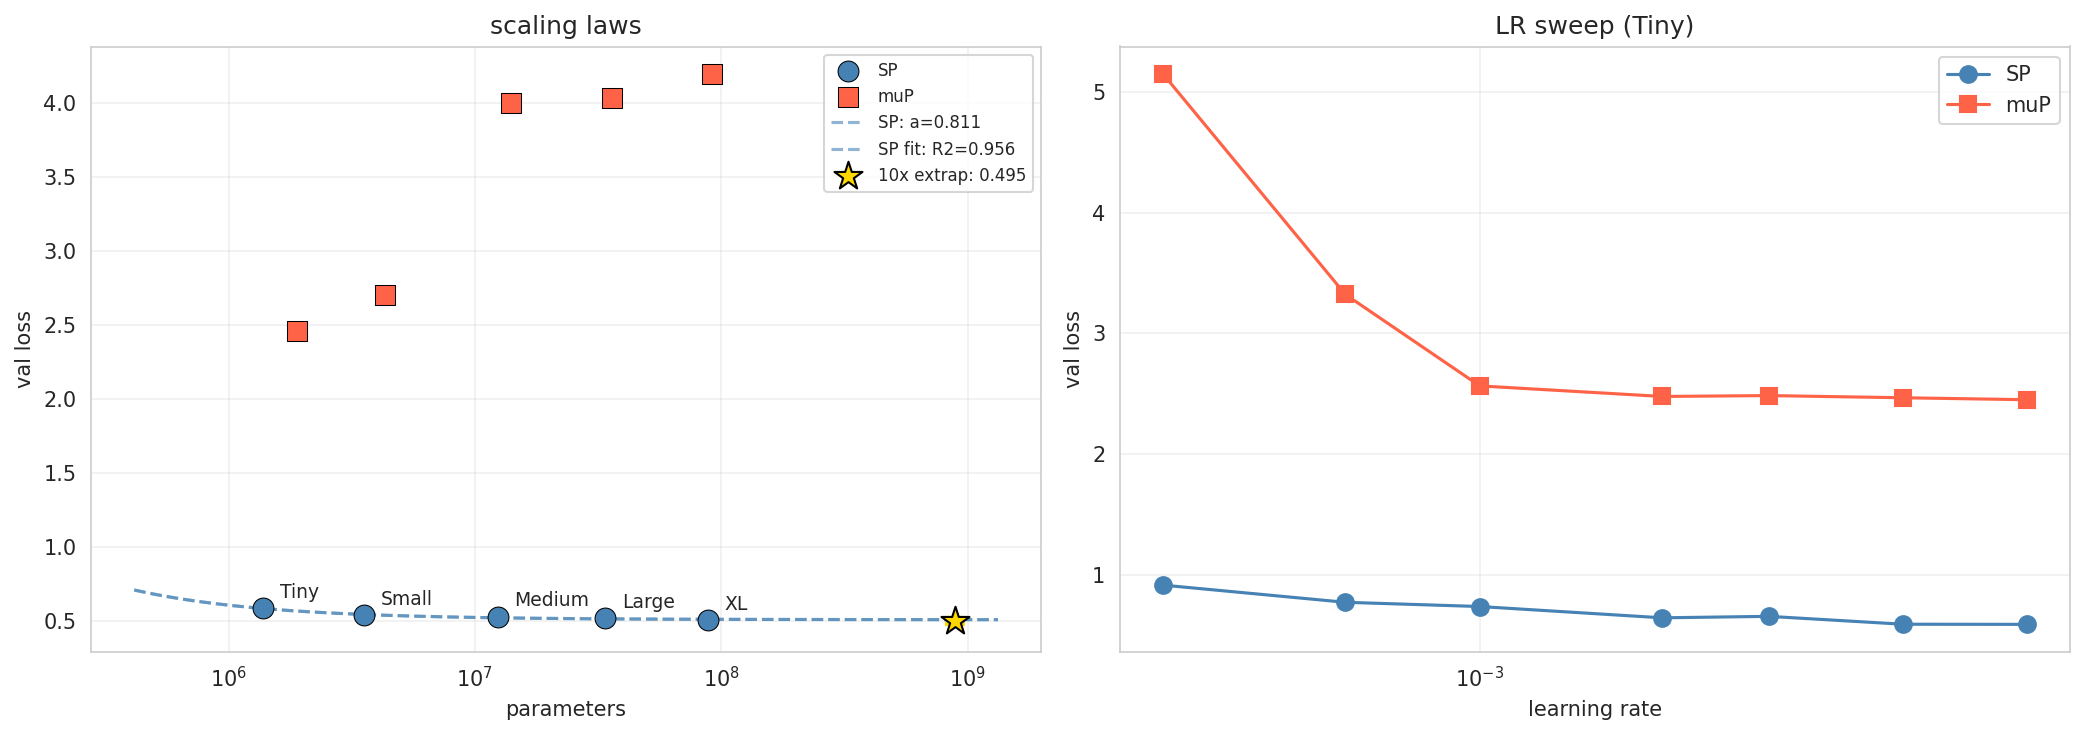

In [6]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
ax=axes[0]
ax.scatter(sp_params,sp_losses,s=100,c="steelblue",zorder=5,edgecolors="k",lw=0.5,label="SP")
ax.scatter(mup_params,mup_losses,s=100,c="tomato",marker="s",zorder=5,edgecolors="k",lw=0.5,label="muP")
ax.plot(xf,power_law(xf,*popt_sp),"--",color="steelblue",alpha=0.6,label=f"SP: a={sp_fit['alpha']:.3f}")
# simplified label
ax.plot(xf,power_law(xf,*popt_sp),"--",color="steelblue",alpha=0.6,label=f"SP fit: R2={sp_fit['r2']:.3f}")
if mup_fit["r2"]>0:ax.plot(xf,power_law(xf,*popt_mup),"--",color="tomato",alpha=0.6,label=f"muP fit: R2={mup_fit['r2']:.3f}")
ext_p=extrap["target_params"]
ax.scatter([ext_p],[extrap["predicted"]],s=200,c="gold",marker="*",zorder=10,edgecolors="k",label=f"10x extrap: {extrap['predicted']:.3f}")
ax.errorbar(ext_p,extrap["predicted"],yerr=[[extrap["predicted"]-extrap["ci_95"][0]],[extrap["ci_95"][1]-extrap["predicted"]]],color="gold",capsize=5,capthick=2,zorder=9)
for n,p,l in zip(MODELS,sp_params,sp_losses):ax.annotate(n,(p,l),textcoords="offset points",xytext=(8,5),fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("parameters")
ax.set_ylabel("val loss")
ax.set_title("scaling laws")
ax.legend(fontsize=8)
ax.grid(True,alpha=0.3)
ax=axes[1]
ax.semilogx([r["lr"] for r in lr_sp["results"]],[r["val"] for r in lr_sp["results"]],"o-",color="steelblue",ms=8,label="SP")
ax.semilogx([r["lr"] for r in lr_mup["results"]],[r["val"] for r in lr_mup["results"]],"s-",color="tomato",ms=8,label="muP")
ax.set_xlabel("learning rate")
ax.set_ylabel("val loss")
ax.set_title("LR sweep (Tiny)")
ax.legend()
ax.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig(f"{DRIVE}/plots/scaling_final.png",dpi=200)
plt.show()

## 5.3 Numbers for the report

In [7]:
print("="*55)
print("NUMBERS FOR THE REPORT")
print("="*55)
print(f"\nDATASET: vocab={meta['vocab_size']}, train={meta['train_tokens']:,}, val={meta['val_tokens']:,}, test={meta['test_tokens']:,}")
print(f"\nMODEL SIZES:")
for n in MODELS:print(f"  {n:<8}: {_pc(sp_res,n):>10,} params")
print(f"\nSCALING (scaled-LR SP):")
print(f"  {'model':<8} {'SP val':>9} {'muP val':>9}")
for n in MODELS:print(f"  {n:<8} {sp_res[n]['val']:>9.4f} {mup_res[n]['val']:>9.4f}")
print(f"\nPOWER LAW: SP a={sp_fit['alpha']:.4f} R2={sp_fit['r2']:.4f}")
print(f"  muP a={mup_fit['alpha']:.4f} R2={mup_fit['r2']:.4f}")
print(f"\nEXTRAP ({extrap['target_params']:,}): {extrap['predicted']:.4f} [{extrap['ci_95'][0]:.4f},{extrap['ci_95'][1]:.4f}]")
print(f"\nGENERATION: ppl={metrics['test_ppl']:.2f}, xml={metrics.get('valid_xml',0)*100:.1f}%, render={metrics.get('renderable',0)*100:.1f}%")

NUMBERS FOR THE REPORT

DATASET: vocab=4096, train=112,654,174, val=1,139,210, test=1,165,205

MODEL SIZES:
  Tiny    :  1,381,120 params
  Small   :  3,549,696 params
  Medium  : 12,407,808 params
  Large   : 33,863,680 params
  XL      : 88,558,080 params

SCALING (scaled-LR SP):
  model       SP val   muP val
  Tiny        0.5834    2.4609
  Small       0.5348    2.7032
  Medium      0.5266    3.9972
  Large       0.5159    4.0330
  XL          0.5017    4.1961

POWER LAW: SP a=0.8107 R2=0.9559
  muP a=2.1992 R2=-0.0000

EXTRAP (885,580,800): 0.4947 [0.4745,0.5187]

GENERATION: ppl=1.57, xml=54.0%, render=54.0%


## 5.4 Design decisions (markdown)See Part 5 markdown cells in the original notebook for detailed write-ups on:- Tokenization strategy (BPE, vocab 4096)- Architecture choices (decoder-only GPT, pre-norm, weight tying)- Training decisions (AdamW, cosine LR, bfloat16)- Scaling insights vs Kaplan/Hoffmann- µP implementation and lessons learned- SVG-specific patterns at different scales- Challenges encountered